In [1]:
from torch import nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

from model_stuff import Predictor
from Rollout import train_rollout
from SingleModel import SingleModel

In [2]:
X_df = pd.read_csv('../data/CESMDataset_Try.csv')
model_vars   = ['AMOC', 'SFWF', 'PD_200m']
feature_cols = target_cols = model_vars
train_cut_1, train_cut_2 = 5000, 11000
train_idx = list(range(train_cut_1)) + list(range(train_cut_2, len(X_df)))

# Per-variable scalers — used to build X_scaled for training, and as y_scalers for predict
y_scalers = {}
X_scaled  = X_df[model_vars].copy().astype(float)
for var in model_vars:
    sc = StandardScaler().fit(X_df[var].values[train_idx].reshape(-1, 1))
    X_scaled[var] = sc.transform(X_df[var].values.reshape(-1, 1))
    y_scalers[var] = sc

# 2D x_scaler for SingleModel.predict — fit on feature columns of training data
x_scaler = StandardScaler().fit(X_df[feature_cols].values[train_idx])


In [3]:
transition_prob = 0.7
threshold = 7
amoc_std = y_scalers['AMOC'].scale_[0]
threshold_scaled = threshold / amoc_std
search_ahead = 100




model = Predictor(n_features=3, hidden_size=64, num_layers=1, dropout=0.1, output_size=3)
feature_cols = target_cols = ['AMOC', 'SFWF', 'PD_200m']

train_rollout(X_scaled, train_cut_1, train_cut_2, transition_prob, threshold_scaled,
              search_ahead, model, feature_cols, target_cols,
              train_steps=300, lag=100, train_horizon=80, loss_fn=nn.MSELoss(), lr=1e-3)

single = SingleModel.from_trained(model, x_scaler, y_scalers)


In [4]:
start_idx = 8500

preds  = single.predict(X_df, start_idx, feature_cols, target_cols, lag=100, steps=5000, threshold=14, rho=0.8, k=0.2)

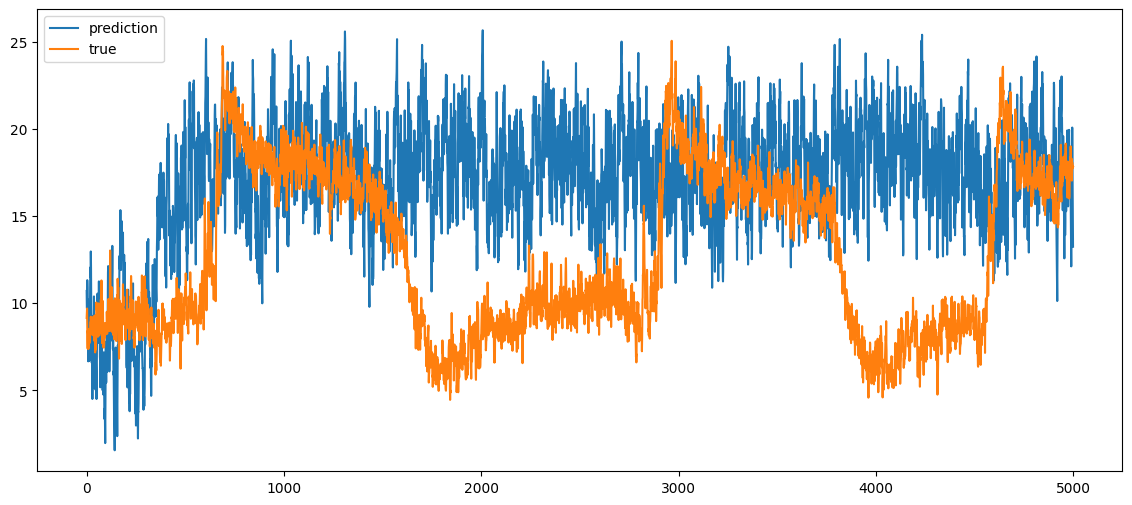

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

x = np.arange(5000)

plt.plot(x, preds['AMOC'], label = 'prediction')
plt.plot(x, X_df['AMOC'][start_idx:start_idx+5000], label = 'true')
plt.legend()

(array([  1.,   3.,   3.,  10.,  22.,  23.,  61.,  74., 112., 115., 165.,
        187., 201., 223., 255., 261., 254., 297., 407., 432., 546., 653.,
        704., 806., 823., 844., 775., 633., 559., 422., 359., 262., 197.,
        157., 127., 105.,  81.,  64.,  71.,  56.,  47.,  39.,  30.,  47.,
         25.,  43.,  42.,  42.,  60.,  59.,  67.,  78.,  77.,  95., 114.,
        151., 180., 189., 199., 191., 199., 225., 179., 224., 155., 177.,
        151., 153., 120., 126.,  93., 110., 112.,  66.,  63.,  59.,  60.,
         53.,  33.,  43.,  38.,  29.,  22.,  30.,  22.,  20.,  19.,  20.,
          9.,  13.,   9.,  12.,   6.,   9.,   4.,   3.,   1.,   1.,   2.,
          1.]),
 array([ 3.8503182 ,  4.06229636,  4.27427452,  4.48625267,  4.69823083,
         4.91020899,  5.12218715,  5.33416531,  5.54614346,  5.75812162,
         5.97009978,  6.18207794,  6.3940561 ,  6.60603425,  6.81801241,
         7.02999057,  7.24196873,  7.45394689,  7.66592504,  7.8779032 ,
         8.08988136,  8.30

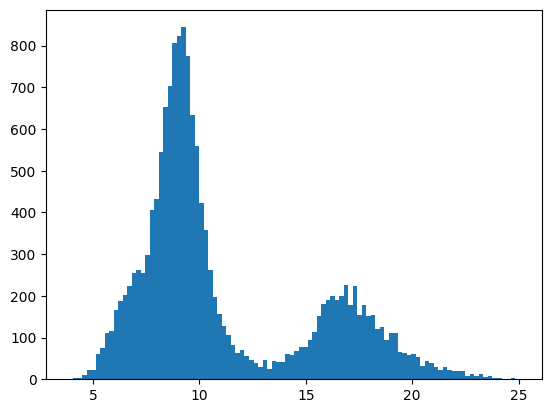

In [27]:
plt.hist(X_df['AMOC'], bins = 100)

Text(0.5, 1.0, 'AMOC distribution in training data only')

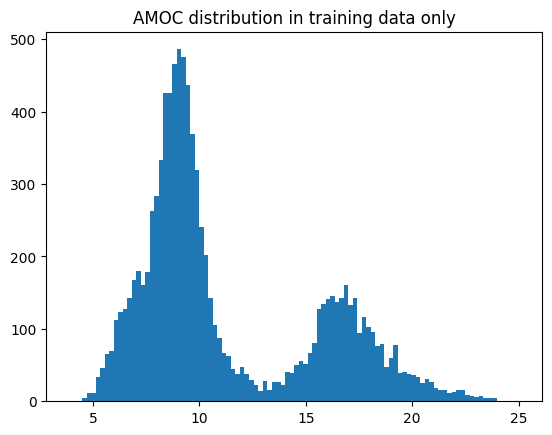

In [28]:
import matplotlib.pyplot as plt
train_amoc = pd.concat([X_df['AMOC'].iloc[:train_cut_1], 
                         X_df['AMOC'].iloc[train_cut_2:]])
plt.hist(train_amoc, bins=100)
plt.title('AMOC distribution in training data only')


In [8]:
def _sample_transitions(X, threshold, search_ahead, lag):
    transition_starts = []
    normal_starts     = []
    for w in range(lag, len(X) - lag - search_ahead):
        future = X['AMOC'].iloc[w + lag : w + lag + search_ahead]
        if future.max() - future.min() > threshold:
            transition_starts.append(w)
        else:
            normal_starts.append(w)
    return transition_starts, normal_starts

Text(0.5, 0, 'AMOC (scaled)')

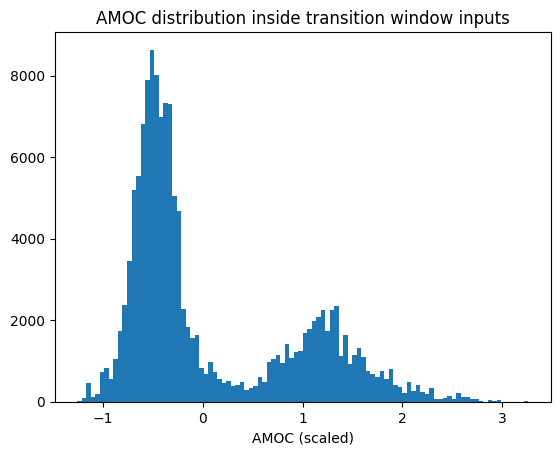

In [9]:
lag = 100

transitions, normal = _sample_transitions(X_scaled[:train_cut_1], threshold_scaled, search_ahead, lag)
# Add chunk 2 offsets
transitions2, normal2 = _sample_transitions(X_scaled[train_cut_2:], threshold_scaled, search_ahead, lag)
all_transitions = transitions + [w + train_cut_2 for w in transitions2]

# Collect all AMOC values from inside the transition input windows
amoc_in_windows = []
for w in all_transitions:
    amoc_in_windows.extend(X_scaled['AMOC'].iloc[w : w + lag].values)

plt.hist(amoc_in_windows, bins=100)
plt.title('AMOC distribution inside transition window inputs')
plt.xlabel('AMOC (scaled)')


Text(0.5, 1.0, 'AMOC distribution in transition window futures (y_w)')

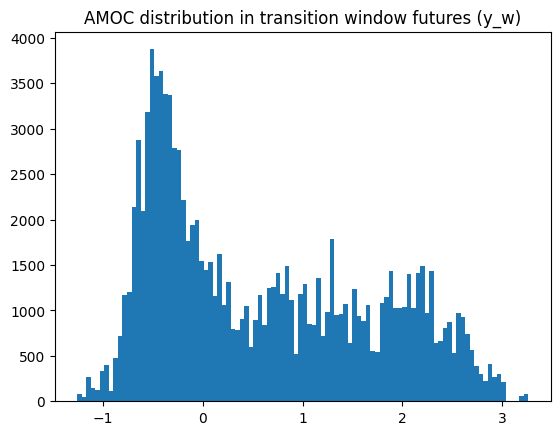

In [10]:
train_horizon = 80

amoc_in_futures = []
for w in all_transitions:
    amoc_in_futures.extend(X_scaled['AMOC'].iloc[w + lag : w + lag + train_horizon].values)

plt.hist(amoc_in_futures, bins=100)
plt.title('AMOC distribution in transition window futures (y_w)')


In [11]:
on_to_off = 0
off_to_on = 0

for w in all_transitions:
    future = X_scaled['AMOC'].iloc[w + lag : w + lag + search_ahead]
    delta = future.iloc[-1] - future.iloc[0]
    if delta > 0:
        off_to_on += 1
    else:
        on_to_off += 1

print(f"on→off: {on_to_off}")
print(f"off→on: {off_to_on}")
print(f"ratio:  {off_to_on / on_to_off:.2f}x more off→on")


on→off: 515
off→on: 896
ratio:  1.74x more off→on


In [12]:
import random

on_to_off_idx = []
off_to_on_idx  = []

for w in all_transitions:
    future = X_scaled['AMOC'].iloc[w + lag : w + lag + search_ahead]
    if future.iloc[-1] - future.iloc[0] > 0:
        off_to_on_idx.append(w)
    else:
        on_to_off_idx.append(w)

random.shuffle(off_to_on_idx)
balanced_transitions = on_to_off_idx + off_to_on_idx[:len(on_to_off_idx)]
print(f"on→off: {len(on_to_off_idx)}, off→on after trim: {len(off_to_on_idx[:len(on_to_off_idx)])}")


on→off: 515, off→on after trim: 515


Text(0.5, 1.0, 'Mean AMOC in on→off input windows')

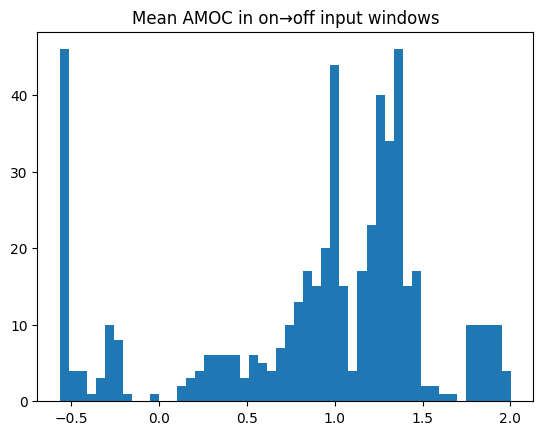

In [14]:
def _balance_transitions(X, transitions, lag, search_ahead):
    on_to_off, off_to_on = [], []
    for w in transitions:
        future = X['AMOC'].iloc[w + lag : w + lag + search_ahead]
        if future.iloc[-1] - future.iloc[0] < 0:
            on_to_off.append(w)
        else:
            off_to_on.append(w)
    n = min(len(on_to_off), len(off_to_on))
    rng = np.random.default_rng()
    return (list(rng.choice(on_to_off, n, replace=False)) +
            list(rng.choice(off_to_on, 1, replace=False)))

on_to_off_idx = _balance_transitions(X_df, all_transitions, lag, search_ahead)

on_to_off_input_means = [X_scaled['AMOC'].iloc[w : w + lag].mean() for w in on_to_off_idx]
plt.hist(on_to_off_input_means, bins=50)
plt.title('Mean AMOC in on→off input windows')


Text(0.5, 1.0, 'Eval region AMOC — pick windows manually')

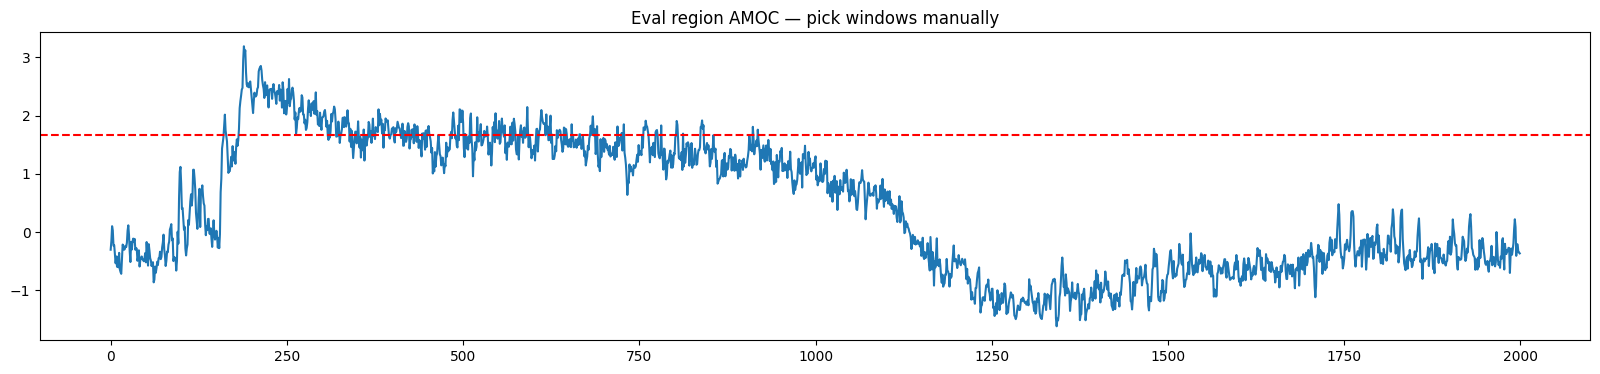

In [28]:
plt.figure(figsize=(20, 4))
plt.plot(X_scaled['AMOC'].iloc[9000:11000].values)
plt.axhline(y=threshold_scaled, color='r', linestyle='--')
plt.title('Eval region AMOC — pick windows manually')


In [ ]:
#off -> on
[6300, 6700]
[9000, 9400]

#on -> off
[6600, 7000]
[9900, 10300]
